# Data Reduction Using UMAP demonstration in Python

## Background

- Data on national athletics records for various countries is available.

- Data Source: Applied Multivariate Statistical Analysis by Richard A. Johnson , Dean W. Wichern

- Sample size is 55 countries' athletics  records for 8  different athletics events – 100 meters to Marathon

Since each country is described by multiple performance variables, the data is inherently high-dimensional. In such scenarios, direct visualization and traditional distance-based methods often fail to reveal meaningful patterns due to data sparsity. To overcome this, t-Distributed Stochastic Neighbor Embedding (t-SNE) is used as a non-linear dimensionality reduction technique. t-SNE effectively preserves local similarities, enabling visualization of complex structures and natural groupings among countries based on athletics performance.

## Objectives

The objectives of this notebook are:

- Understand the need for non-linear dimensionality reduction in high-dimensional data

- Learn the intuition and working principles of t-Distributed Stochastic Neighbor Embedding (t-SNE)

- Visualize high-dimensional data in 2D/3D using t-SNE embeddings



## Data Description

| Column Name     | Description                                      |
|-----------------|--------------------------------------------------|
| 100m_s          | Time taken to complete 100 meters (seconds)     |
| 200m_s          | Time taken to complete 200 meters (seconds)     |
| 400m_s          | Time taken to complete 400 meters (seconds)     |
| 800m_min        | Time taken to complete 800 meters (minutes)     |
| 1500m_min       | Time taken to complete 1500 meters (minutes)    |
| 5000m_min       | Time taken to complete 5000 meters (minutes)    |
| 10000m_min      | Time taken to complete 10000 meters (minutes)   |
| Marathon_min   | Time taken to complete a marathon (minutes)     |


### Import Libraries

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

#pip install umap-learn
import umap.umap_ as umap

import matplotlib.pyplot as plt


### Import Data

In [11]:
athletics_df = pd.read_csv('Athleticsdata.csv')
#Drop categorical column
athletics = athletics_df.drop(columns=['Country'])
athletics_df.head()

,Country,100m_s,200m_s,400m_s,800m_min,1500m_min,5000m_min,10000m_min,Marathon_min
0,Argentina,10.39,20.81,46.84,1.81,3.70,14.04,29.36,137.72
1,Australia,10.31,20.06,44.84,1.74,3.57,13.28,27.66,128.30
2,Austria,10.44,20.81,46.82,1.79,3.60,13.26,27.72,135.90
3,Belgium,10.34,20.68,45.04,1.73,3.60,13.22,27.45,129.95
4,Bermuda,10.28,20.58,45.91,1.80,3.75,14.68,30.55,146.62


### Standardize the data

In [12]:
scaler = StandardScaler()
athletics_scaled = scaler.fit_transform(athletics)

### Apply UMAP

We project the 8-dimensional athletics performance data into 2D for visualization

- n_neighbors: local vs global structure (small → local clusters, large → global shape)

- n_components: output dimensions (2 for plot, can be >2 for ML)

- min_dist: how tightly points are packed (smaller → tighter clusters)

In [13]:
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    random_state=42
)

athletics_umap = umap_model.fit_transform(athletics_scaled)

### Visualize UMAP Projection

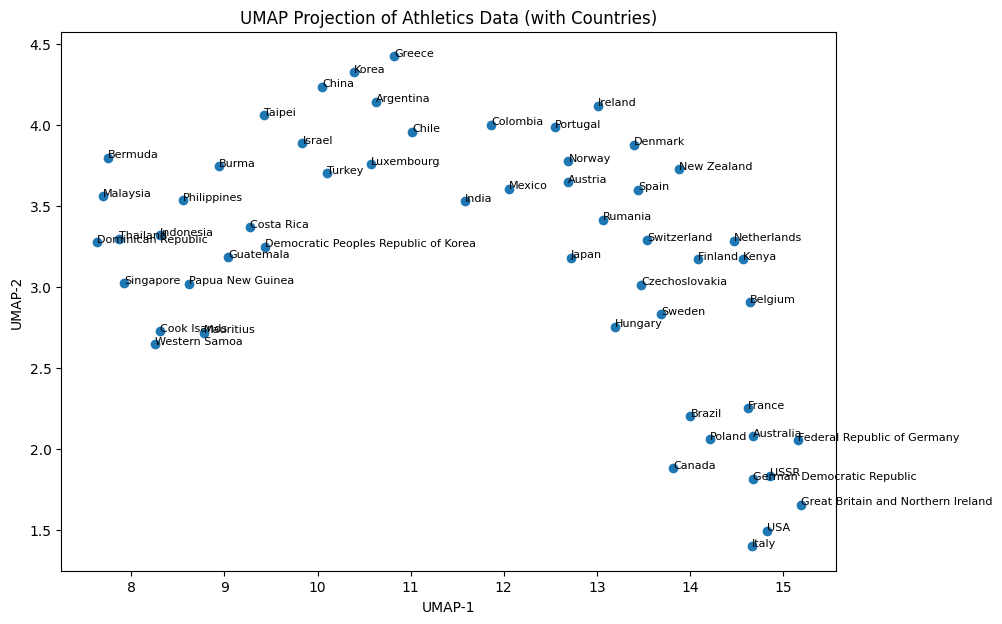

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(athletics_umap[:, 0], athletics_umap[:, 1])

for i, country in enumerate(athletics_df['Country']):  # or your country column
    plt.text(athletics_umap[i, 0], athletics_umap[i, 1], country, fontsize=8)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP Projection of Athletics Data (with Countries)")
plt.show()


### Inference :
Countries that are close together have similar athletics profiles, and the clusters show groups of countries with similar performance patterns